C:\Users\amigo\AppData\Local\Temp\ipykernel_24456\3615964575.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  comp_plot = sns.barplot(


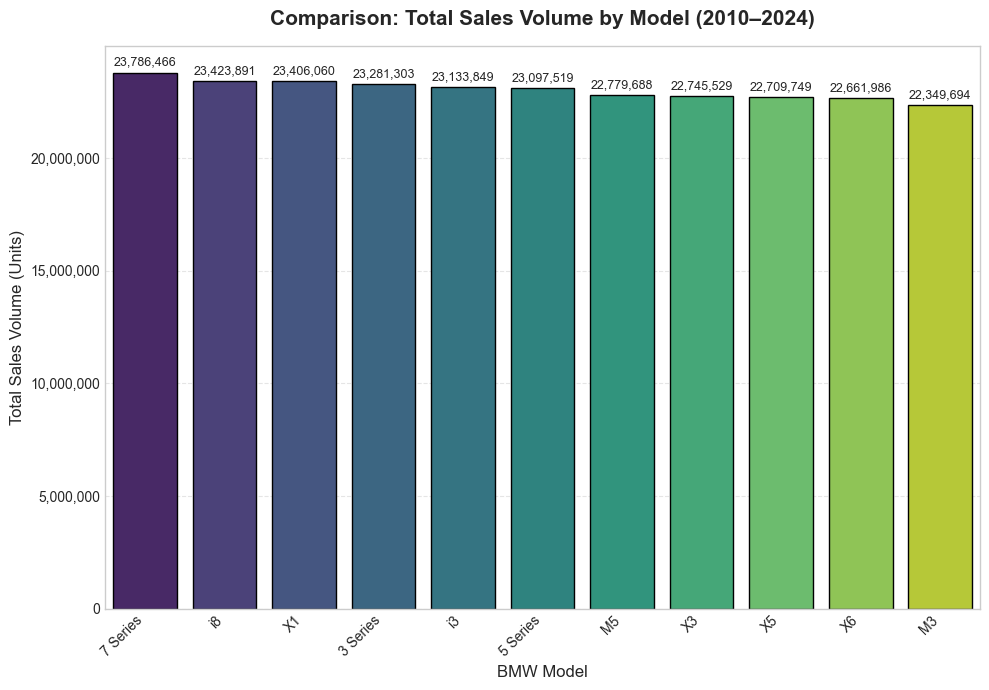

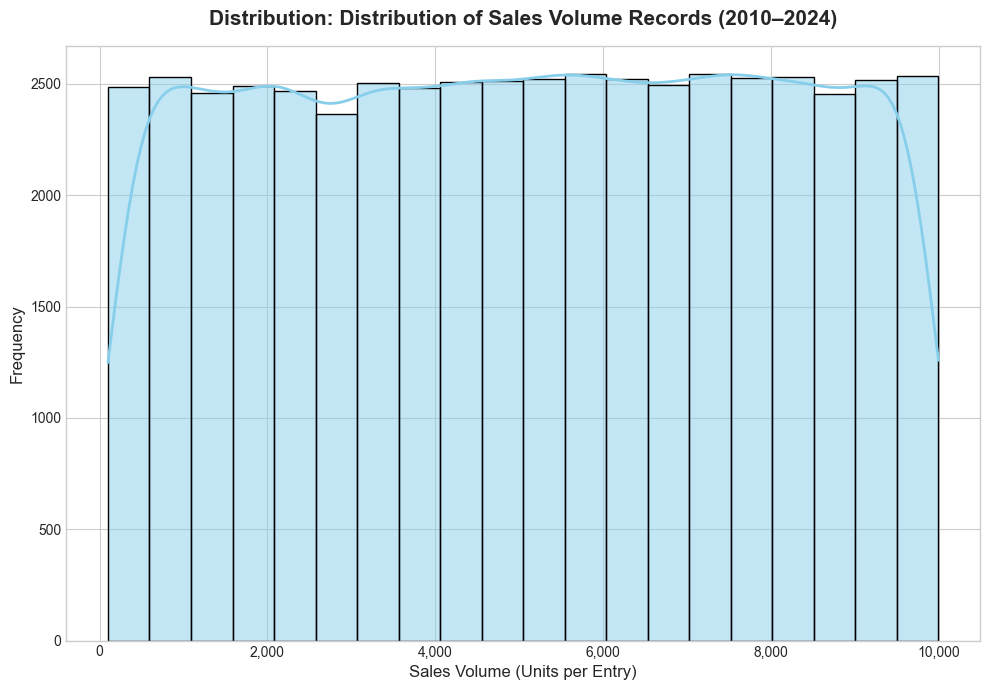

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

FILE_PATH = 'BMW sales data (2010-2024).csv'
plt.style.use('seaborn-v0_8-whitegrid')

try:
    df = pd.read_csv(FILE_PATH)
    df['Sales_Volume'] = pd.to_numeric(df['Sales_Volume'], errors='coerce')
    df.dropna(subset=['Sales_Volume'], inplace=True)
    model_sales = df.groupby('Model')['Sales_Volume'].sum().reset_index()
    model_sales = model_sales.sort_values(by='Sales_Volume', ascending=False)

    plt.figure(figsize=(10, 7))
    comp_plot = sns.barplot(
        x='Model',
        y='Sales_Volume',
        data=model_sales,
        palette='viridis',
        edgecolor='black'
    )
    for container in comp_plot.containers:
        comp_plot.bar_label(container, fmt='{:,.0f}', padding=3, fontsize=9)
    formatter = ticker.StrMethodFormatter('{x:,.0f}')
    comp_plot.yaxis.set_major_formatter(formatter)

    plt.title(
        'Comparison: Total Sales Volume by Model (2010–2024)',
        fontsize=15,
        fontweight='bold',
        pad=15
    )
    plt.xlabel('BMW Model', fontsize=12)
    plt.ylabel('Total Sales Volume (Units)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig('task1_comparison.png', dpi=300)
    plt.show()
    plt.figure(figsize=(10, 7))

    dist_plot = sns.histplot(
        data=df,
        x='Sales_Volume',
        bins=20,
        kde=True,
        color='skyblue',
        edgecolor='black',
        line_kws={'linewidth': 2}
    )

    dist_plot.xaxis.set_major_formatter(formatter)
    plt.title(
        'Distribution: Distribution of Sales Volume Records (2010–2024)',
        fontsize=15,
        fontweight='bold',
        pad=15
    )
    plt.xlabel('Sales Volume (Units per Entry)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.tight_layout()
    plt.savefig('task1_distribution.png', dpi=300)
    plt.show()

except FileNotFoundError:
    print(f"Error: File '{FILE_PATH}' not found. Please ensure the file is in the correct directory.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


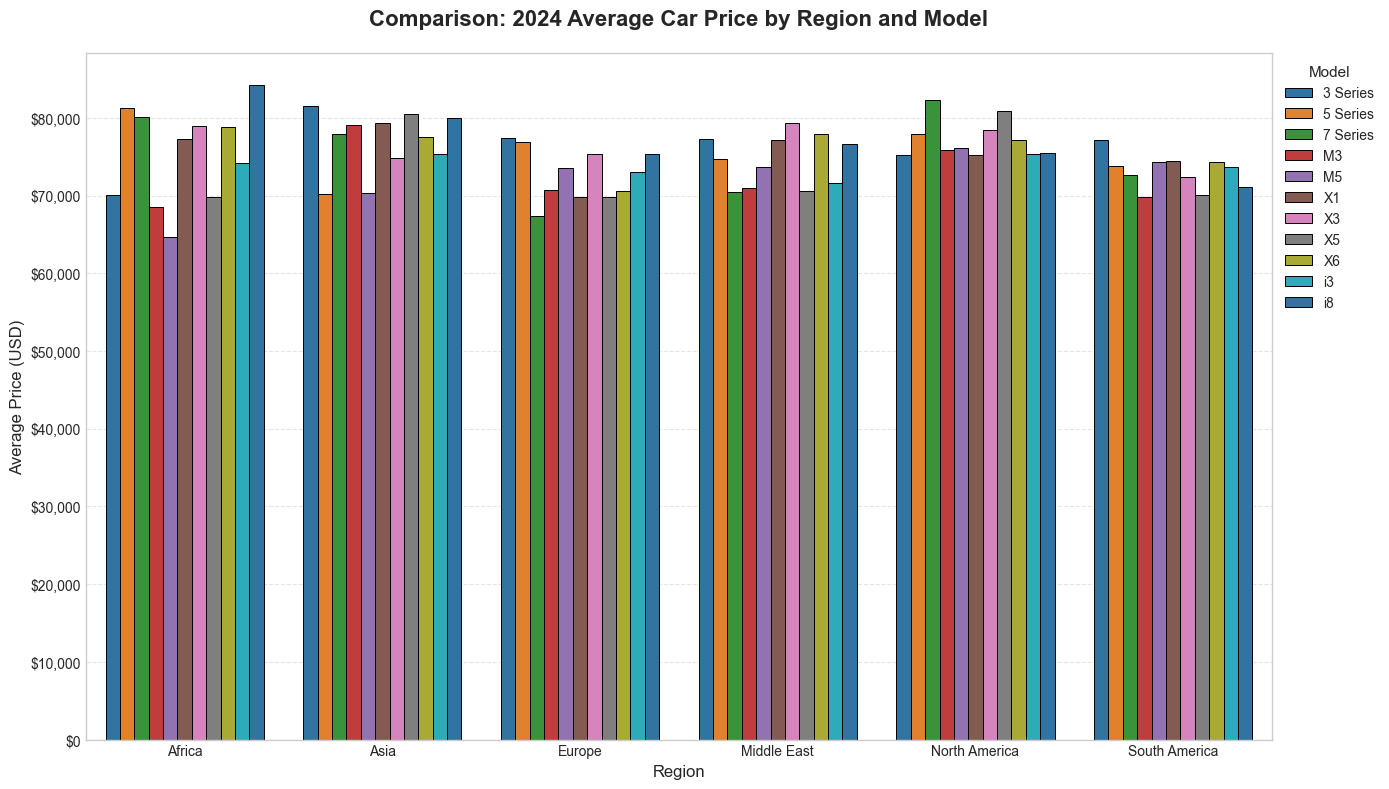

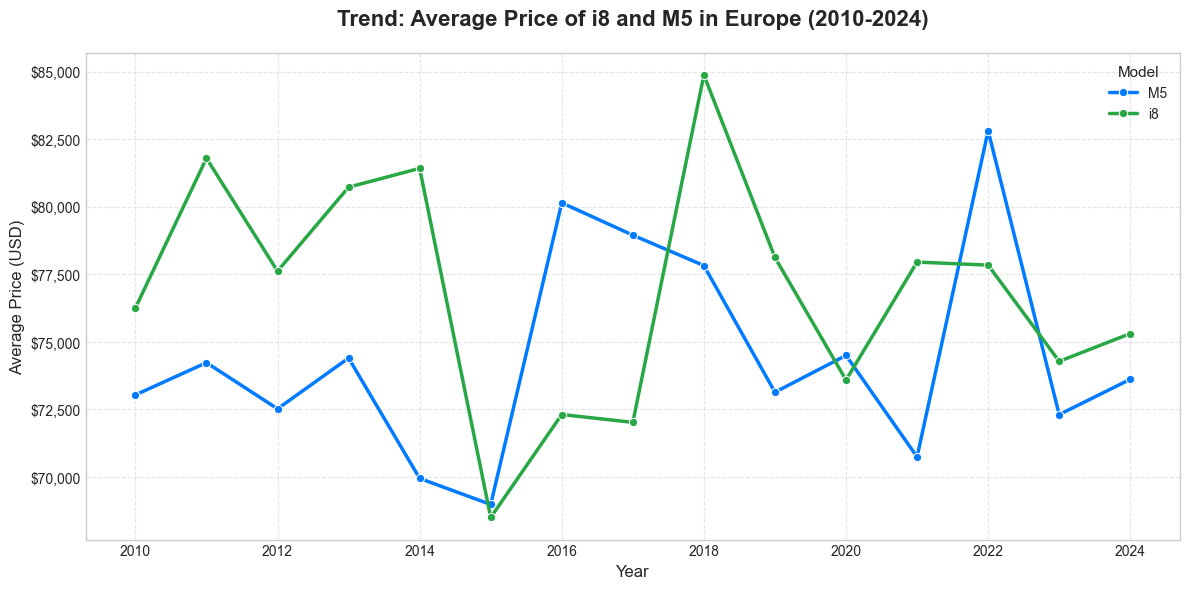

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

plt.style.use('seaborn-v0_8-whitegrid')
FILE_PATH = 'BMW sales data (2010-2024).csv'

try:
    df = pd.read_csv(FILE_PATH)
    df['Year'] = df['Year'].astype(int)
    df['Price_USD'] = pd.to_numeric(df['Price_USD'], errors='coerce')
    df_2024 = df[df['Year'] == 2024].copy()
    avg_price_2024 = df_2024.groupby(['Region', 'Model'])['Price_USD'].mean().reset_index()
    avg_price_2024.rename(columns={'Price_USD': 'Average_Price_USD'}, inplace=True)

    plt.figure(figsize=(14, 8))
    bar_plot = sns.barplot(
        x='Region',
        y='Average_Price_USD',
        hue='Model',
        data=avg_price_2024,
        palette='tab10',
        edgecolor='black',
        linewidth=0.7
    )

    formatter = ticker.StrMethodFormatter('${x:,.0f}')
    bar_plot.yaxis.set_major_formatter(formatter)

    plt.title(
        'Comparison: 2024 Average Car Price by Region and Model',
        fontsize=16,
        fontweight='bold',
        pad=20
    )
    plt.xlabel('Region', fontsize=12)
    plt.ylabel('Average Price (USD)', fontsize=12)
    plt.legend(title='Model', title_fontsize=11, fontsize=10, loc='upper left', bbox_to_anchor=(1, 1))
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig('task2_avg_price_2024_comparison.png', dpi=300)
    plt.show()
    df_europe = df[(df['Region'] == 'Europe') & (df['Year'] >= 2010) & (df['Year'] <= 2024)].copy()
    top_models_europe = df_europe.groupby('Model')['Sales_Volume'].sum().nlargest(2).index.tolist()

    if len(top_models_europe) < 2:
        print(f"\nCould only find {len(top_models_europe)} model(s) in Europe for 2010-2024. Skipping Price Trend plot.")
    else:
        df_top2_trend = df_europe[df_europe['Model'].isin(top_models_europe)]
        price_trend = df_top2_trend.groupby(['Year', 'Model'])['Price_USD'].mean().reset_index()
        price_trend.rename(columns={'Price_USD': 'Average_Price_USD'}, inplace=True)

        plt.figure(figsize=(12, 6))
        line_plot = sns.lineplot(
            x='Year',
            y='Average_Price_USD',
            hue='Model',
            data=price_trend,
            marker='o',
            linewidth=2.5,
            palette=['#007bff', '#28a745']
        )

        line_plot.yaxis.set_major_formatter(formatter)
        line_plot.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

        plt.title(
            f'Trend: Average Price of {top_models_europe[0]} and {top_models_europe[1]} in Europe (2010-2024)',
            fontsize=16,
            fontweight='bold',
            pad=20
        )
        plt.xlabel('Year', fontsize=12)
        plt.ylabel('Average Price (USD)', fontsize=12)
        plt.legend(title='Model', title_fontsize=11, fontsize=10)
        plt.grid(axis='both', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.savefig('task2_europe_price_trend.png', dpi=300)
        plt.show()

except FileNotFoundError:
    print(f"Error: File '{FILE_PATH}' not found. Please ensure the file is in the correct directory.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

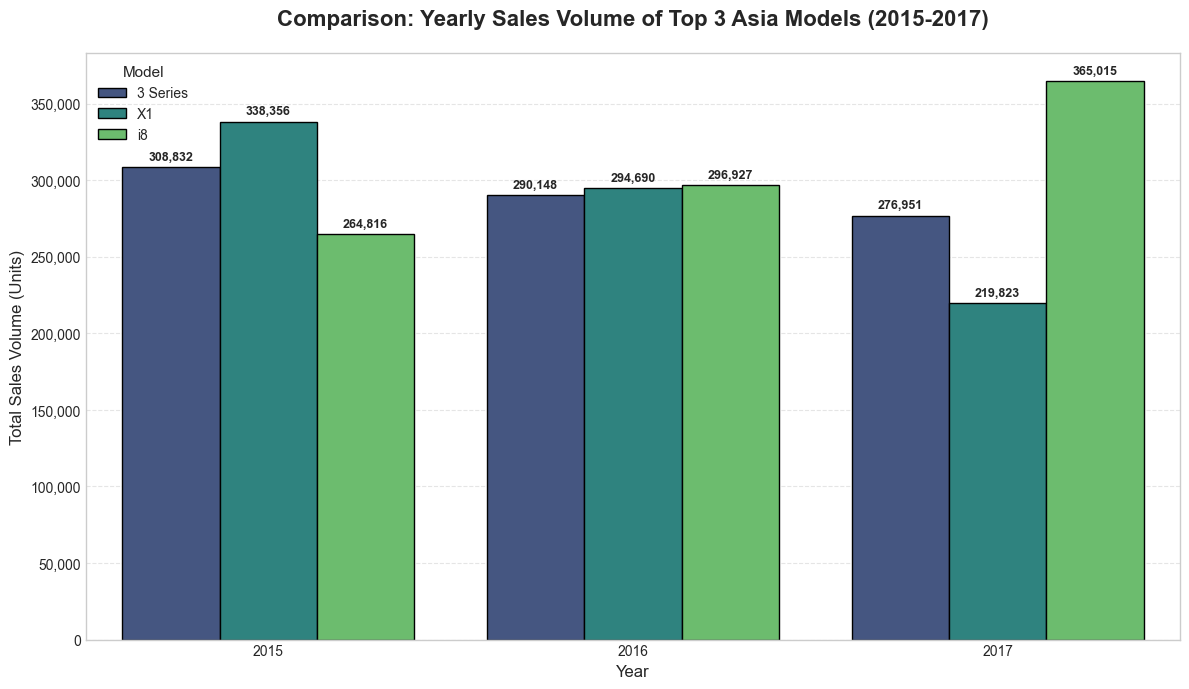

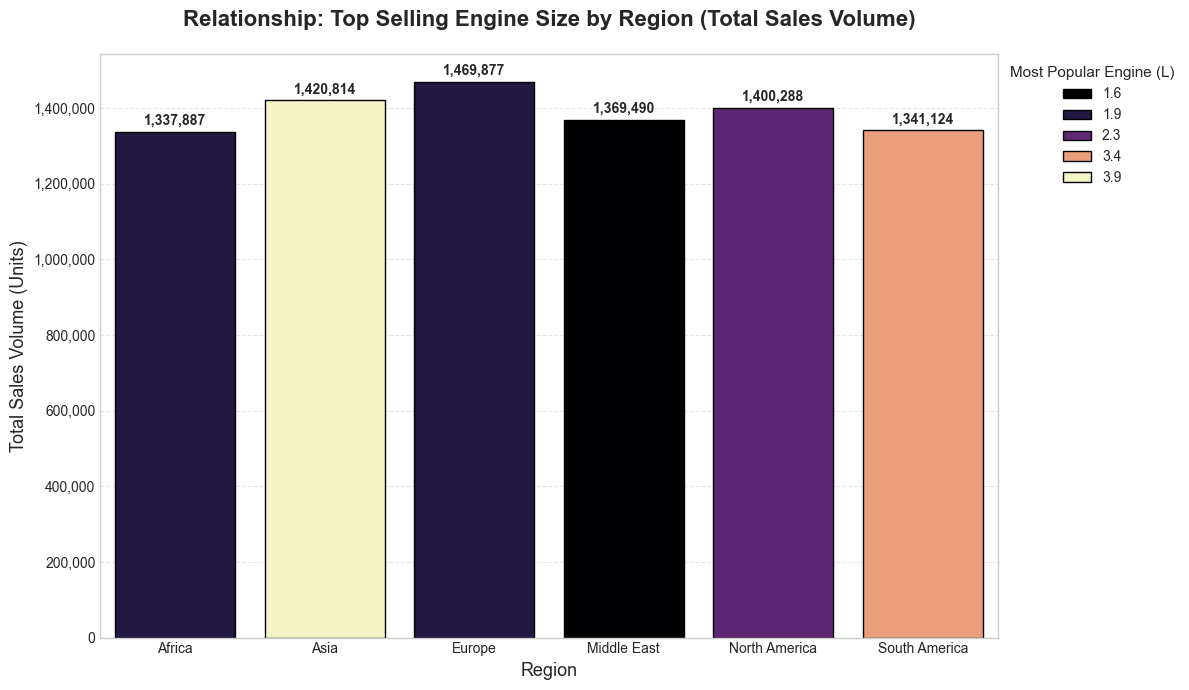

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

FILE_PATH = 'BMW sales data (2010-2024).csv'

plt.style.use('seaborn-v0_8-whitegrid')

try:
    df = pd.read_csv(FILE_PATH)
    df['Year'] = df['Year'].astype(int)
    target_years = [2015, 2016, 2017]
    df_asia_target = df[(df['Region'] == 'Asia') & (df['Year'].isin(target_years))].copy()
    if df_asia_target.empty:
        print(f"No sales data found for Asia between {target_years[0]} and {target_years[-1]}.")
    else:
        model_rank = df_asia_target.groupby('Model')['Sales_Volume'].sum().nlargest(3).index.tolist()
        df_top3_asia = df_asia_target[df_asia_target['Model'].isin(model_rank)]
        plot_data = df_top3_asia.groupby(['Year', 'Model'])['Sales_Volume'].sum().reset_index()
        plot_data['Year'] = plot_data['Year'].astype(str)
        plt.figure(figsize=(12, 7))
        bar_plot = sns.barplot(
            x='Year',
            y='Sales_Volume',
            hue='Model',
            data=plot_data,
            palette='viridis',
            edgecolor='black',
            linewidth=1
        )
        for container in bar_plot.containers:
            bar_plot.bar_label(container, fmt='{:,.0f}', padding=3, fontsize=9, fontweight='bold')

        formatter = ticker.StrMethodFormatter('{x:,.0f}')
        bar_plot.yaxis.set_major_formatter(formatter)

        plt.title(
            f'Comparison: Yearly Sales Volume of Top 3 Asia Models ({target_years[0]}-{target_years[-1]})',
            fontsize=16,
            fontweight='bold',
            pad=20
        )
        plt.xlabel('Year', fontsize=12)
        plt.ylabel('Total Sales Volume (Units)', fontsize=12)
        plt.legend(title='Model', title_fontsize=11, fontsize=10)
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.savefig('task3_top3_asia_sales_histogram_v2.png', dpi=300)
        plt.show()

    # --- Part 2: Relationship Visualization (Regional Engines vs Volume) ---
    region_engine_stats = df.groupby(['Region', 'Engine_Size_L'])['Sales_Volume'].sum().reset_index()
    top_engines_per_region = region_engine_stats.loc[region_engine_stats.groupby('Region')['Sales_Volume'].idxmax()]

    plt.figure(figsize=(12, 7))
    bar_plot = sns.barplot(
        x='Region',
        y='Sales_Volume',
        hue='Engine_Size_L',
        data=top_engines_per_region,
        palette='magma',
        dodge=False,
        edgecolor='black',
        linewidth=1
    )

    for container in bar_plot.containers:
        bar_plot.bar_label(container, fmt='{:,.0f}', padding=3, fontsize=10, fontweight='bold')

    plt.title('Relationship: Top Selling Engine Size by Region (Total Sales Volume)', fontsize=16,
              fontweight='bold', pad=20)
    plt.xlabel('Region', fontsize=13)
    plt.ylabel('Total Sales Volume (Units)', fontsize=13)

    plt.legend(title='Most Popular Engine (L)', title_fontsize=11, fontsize=10, loc='upper left', bbox_to_anchor=(1, 1))

    formatter = ticker.StrMethodFormatter('{x:,.0f}')
    bar_plot.yaxis.set_major_formatter(formatter)

    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig('task3_relationship_region_engine_v4.png', dpi=300)
    plt.show()

except FileNotFoundError:
    print(f"Error: File '{FILE_PATH}' not found. Please ensure the file is in the correct directory.")